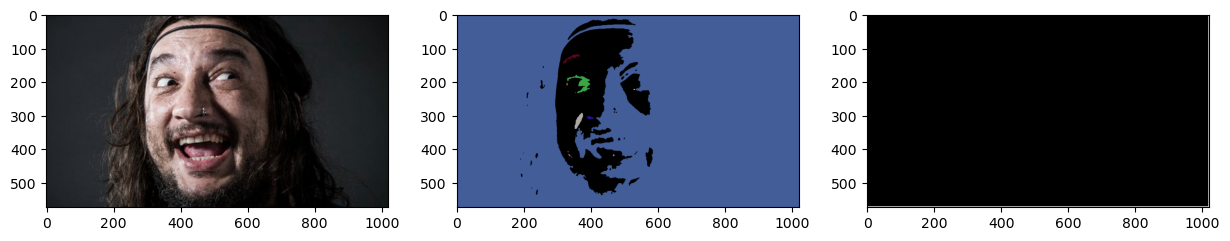

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('bananero.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# combino tecnicas
blur = cv2.GaussianBlur(gray, (7, 7), 0)
_, binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# encontramos las regiones
num_l, label = cv2.connectedComponents(binary)

# identificamos por colores
color = np.random.randint(0, 255, size=(num_l, 3), dtype=np.uint8)

# fondo negro
color[0] = [0, 0, 0]
colorear = color[label]

# encontrar fronteras
contornos, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contorno_fin = cv2.drawContours(np.zeros_like(gray), contornos, -1, 255, 2)

plt.figure(figsize=(15, 5))

plt.subplot(131)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

plt.subplot(132)
plt.imshow(colorear)

plt.subplot(133)
plt.imshow(contorno_fin, cmap='gray')

plt.show()

CONTEO

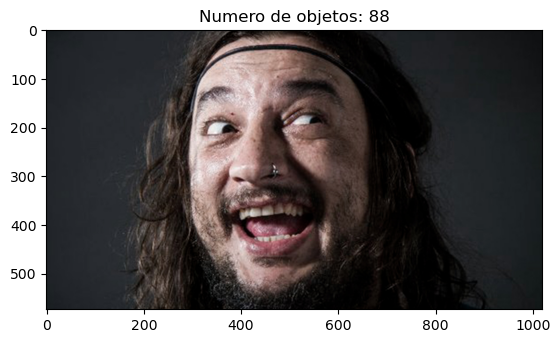

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

def contar_elementos(img):
    gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
    _,binary=cv2.threshold(gray,127,255,cv2.THRESH_BINARY)
    e_img=measure.label(binary,connectivity=2)
    num_obj=np.max(e_img)
    return num_obj

imagen=cv2.imread('bananero.jpg')
conteo=contar_elementos(imagen)
plt.imshow(cv2.cvtColor(imagen,cv2.COLOR_BGR2RGB))
plt.title(f'Numero de objetos: {conteo}')
plt.show()


Total regiones 21
color 169, 253, 234 objetos 507438
color 161, 151, 208 objetos 358
color 36, 192, 187 objetos 2
color 42, 95, 215 objetos 5
color 202, 71, 80 objetos 1242
color 81, 15, 56 objetos 1
color 189, 107, 63 objetos 31
color 166, 206, 247 objetos 12
color 222, 186, 69 objetos 3
color 90, 8, 34 objetos 567
color 182, 226, 155 objetos 133
color 157, 228, 132 objetos 1
color 233, 57, 222 objetos 1
color 197, 203, 218 objetos 1
color 247, 207, 85 objetos 8
color 156, 3, 183 objetos 29
color 186, 138, 61 objetos 24
color 67, 149, 79 objetos 2
color 96, 236, 189 objetos 8
color 166, 92, 196 objetos 2
color 207, 101, 33 objetos 5


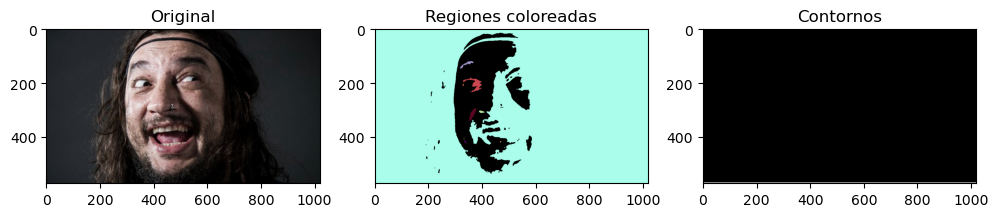


Total regiones 89
color 131, 236, 62 objetos 298064
color 147, 1, 227 objetos 216
color 207, 224, 152 objetos 3
color 183, 216, 127 objetos 541
color 32, 105, 58 objetos 193
color 208, 238, 156 objetos 256
color 133, 222, 229 objetos 1
color 43, 85, 14 objetos 5
color 8, 32, 193 objetos 94
color 11, 47, 189 objetos 15
color 246, 23, 32 objetos 14
color 248, 79, 233 objetos 2
color 74, 193, 167 objetos 318
color 31, 93, 50 objetos 35
color 211, 196, 89 objetos 25
color 68, 89, 49 objetos 155
color 107, 89, 76 objetos 98
color 254, 250, 92 objetos 91
color 204, 222, 146 objetos 174
color 29, 146, 54 objetos 76
color 231, 89, 80 objetos 151
color 29, 17, 191 objetos 171
color 183, 244, 45 objetos 75
color 17, 219, 78 objetos 94
color 30, 207, 173 objetos 150
color 0, 11, 65 objetos 202
color 180, 128, 141 objetos 1
color 1, 238, 160 objetos 78
color 86, 50, 132 objetos 117
color 116, 94, 99 objetos 132
color 93, 118, 80 objetos 172
color 39, 227, 190 objetos 200
color 212, 118, 42 objeto

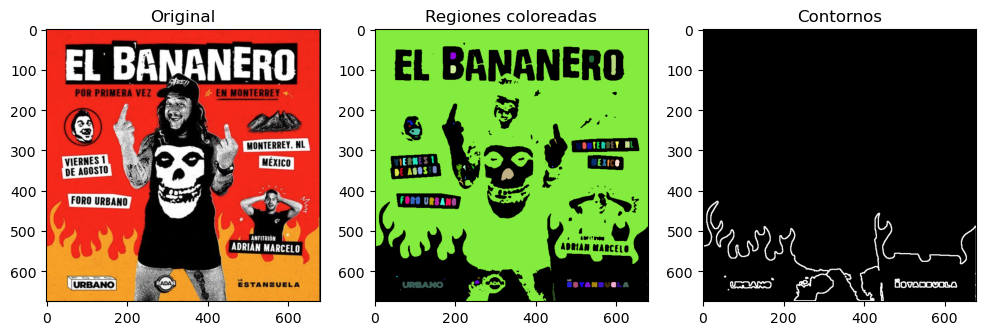


Total regiones 4
color 118, 41, 18 objetos 43149
color 236, 185, 159 objetos 36
color 73, 19, 141 objetos 592
color 119, 144, 176 objetos 23


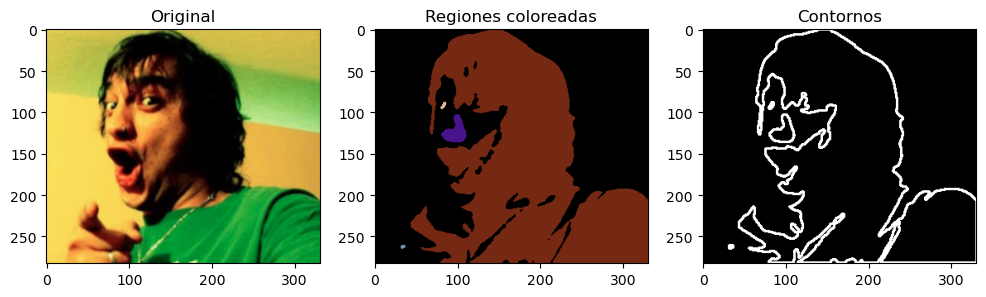

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def procesar_imagen(ruta):
    img = cv2.imread(ruta)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    blur = cv2.GaussianBlur(gray, (7, 7), 0)

    _, binary = cv2.threshold(
        blur,
        0,
        255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    num_labels, labels = cv2.connectedComponents(binary)

    colores = np.random.randint(0, 255, (num_labels, 3), dtype=np.uint8)
    colores[0] = [0, 0, 0]

    imagen_coloreada = colores[labels]

    contornos, _ = cv2.findContours(
        binary,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    contorno_img = np.zeros_like(gray)

    cv2.drawContours(
        contorno_img,
        contornos,
        -1,
        255,
        2
    )

    ids, pixeles = np.unique(labels, return_counts=True)

    print("\nTotal regiones", num_labels - 1)

    for i in range(1, num_labels):
        color = colores[i]

        print(
            f"color {color[0]}, {color[1]}, {color[2]} "
            f"objetos {pixeles[i]}"
        )

    return img, imagen_coloreada, contorno_img


imagenes = [
    'bananero.jpg',
    'bananero2.png',
    'bananero3.png'
]

for ruta in imagenes:

    original, coloreada, contornos = procesar_imagen(ruta)

    plt.figure(figsize=(12, 4))

    plt.subplot(131)
    plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    plt.title('Original')

    plt.subplot(132)
    plt.imshow(coloreada)
    plt.title('Regiones coloreadas')

    plt.subplot(133)
    plt.imshow(contornos, cmap='gray')
    plt.title('Contornos')

    plt.show()